# Time Series Analysis and Forecasting: Monthly International Airline Passengers

**Dataset:** Monthly totals of international airline passengers, 1949-1960  
**Series type:** Real-world univariate time series  
**Forecasting objective:** Forecast monthly passenger demand using classical statistical models and recurrent neural networks.

## 1. Environment Setup

The analysis uses standard Python libraries for time series modeling and neural forecasting. Random seeds are fixed for reproducibility. PyTorch is used for Simple RNN, LSTM, and GRU models, and tensors/models are moved to the GPU automatically when CUDA is available in the `pyX` conda environment.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from statsmodels.tools.sm_exceptions import ConvergenceWarning, InterpolationWarning

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display


SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"PyTorch version: {torch.__version__}")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"PyTorch version: {torch.__version__}")
    print("CUDA is not available; using CPU fallback.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters found.*")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found.*")


PyTorch version: 2.12.1+cu132
Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Dataset Selection, Loading, and Description

The dataset contains monthly international airline passenger counts from 1949 through 1960. It is a classic real-world demand series, originally popularized in Box and Jenkins time series work and widely available through public educational repositories.

The target variable is `Passengers`, measured as thousands of passengers per month. The observation frequency is monthly, which makes seasonal behavior especially important because air travel demand often has yearly cycles.

In [26]:
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(data_url)

df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month").asfreq("MS")
df = df.rename(columns={"Passengers": "passengers"})
series = df["passengers"].astype(float)

print(df.head())
print("\nDataset shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Inferred frequency:", pd.infer_freq(df.index))
print("Missing values:", int(series.isna().sum()))
df.describe().T

            passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Dataset shape: (144, 1)
Date range: 1949-01-01 to 1960-12-01
Inferred frequency: MS
Missing values: 0


,count,mean,std,min,25%,50%,75%,max
passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


## 3. Forecasting Objective and Train-Test Split

The objective is to forecast future monthly passenger counts. The final 20% of observations are reserved as a chronological test set. Time series data must not be randomly shuffled because future observations would leak into model training.

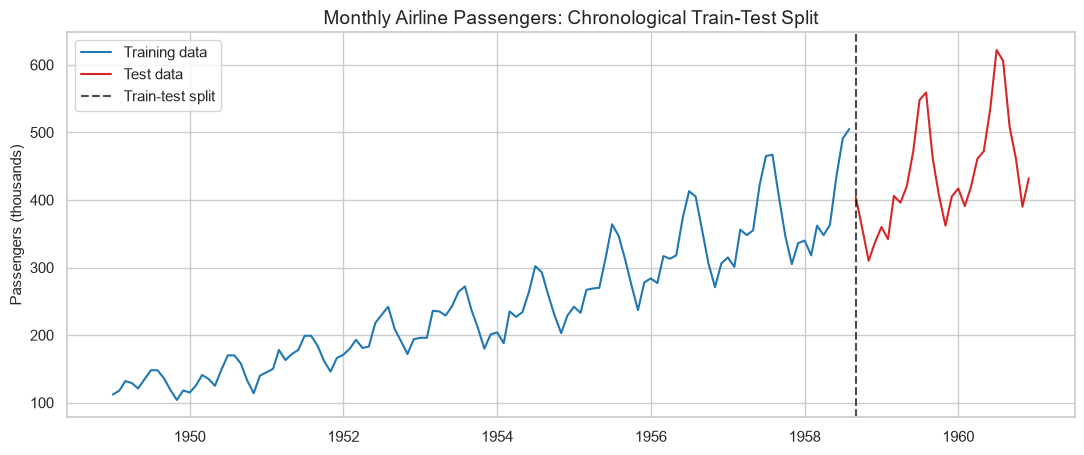

Training observations: 116 (1949-01-01 to 1958-08-01)
Testing observations:  28 (1958-09-01 to 1960-12-01)


In [27]:
test_size = int(len(series) * 0.20)
train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train, label="Training data", color="#1f77b4")
ax.plot(test, label="Test data", color="#d62728")
ax.axvline(test.index[0], color="black", linestyle="--", alpha=0.7, label="Train-test split")
ax.set_title("Monthly Airline Passengers: Chronological Train-Test Split")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

print(f"Training observations: {len(train)} ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing observations:  {len(test)} ({test.index.min().date()} to {test.index.max().date()})")

## 4. Exploratory Time Series Analysis

The raw plot shows a clear upward trend and a repeating yearly cycle. The seasonal swings also become larger as the level of the series increases, suggesting multiplicative seasonality and non-constant variance.

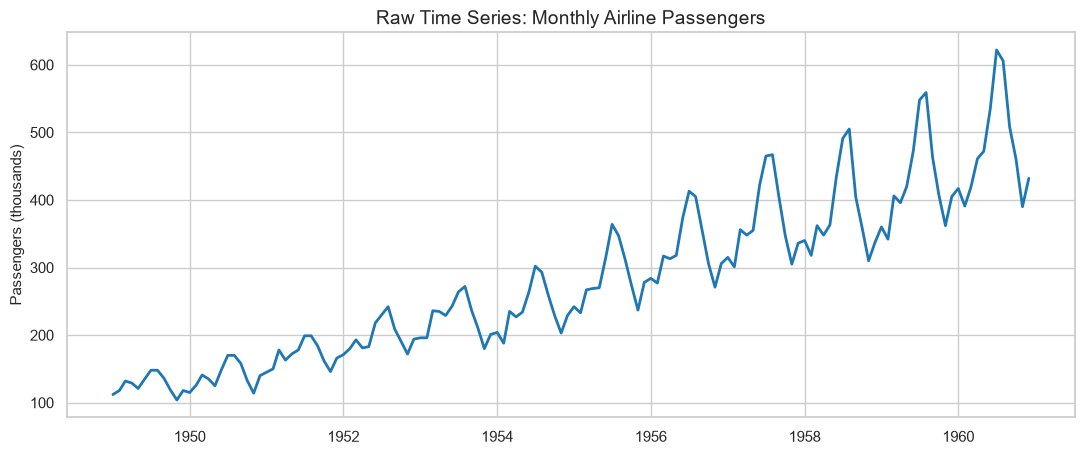

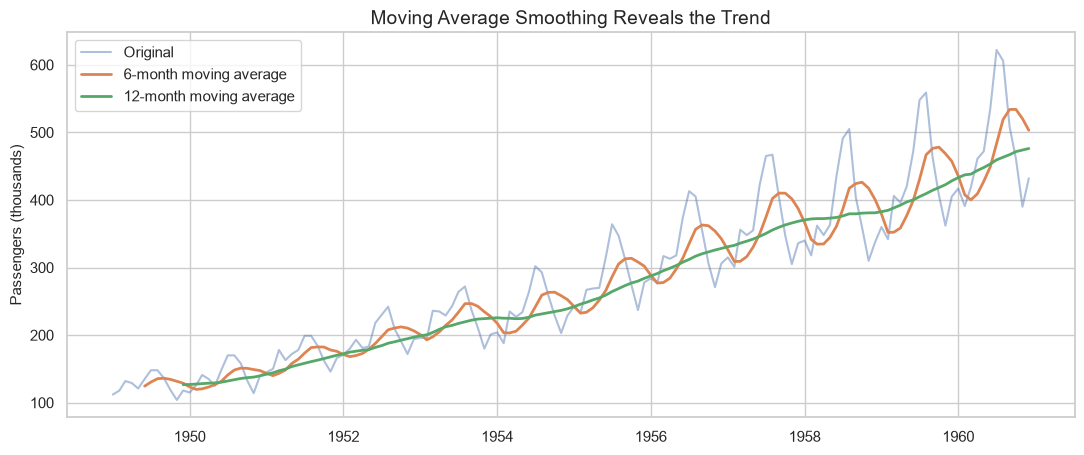

In [28]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series, color="#1f77b4", linewidth=2)
ax.set_title("Raw Time Series: Monthly Airline Passengers")
ax.set_ylabel("Passengers (thousands)")
plt.show()

rolling_12 = series.rolling(window=12).mean()
rolling_6 = series.rolling(window=6).mean()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series, label="Original", alpha=0.45)
ax.plot(rolling_6, label="6-month moving average", linewidth=2)
ax.plot(rolling_12, label="12-month moving average", linewidth=2)
ax.set_title("Moving Average Smoothing Reveals the Trend")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

### Linear Regression Trend Estimation and Significance

A simple time-index regression provides a formal estimate of the trend. A statistically significant positive slope supports the visual conclusion that passenger demand increased over time.

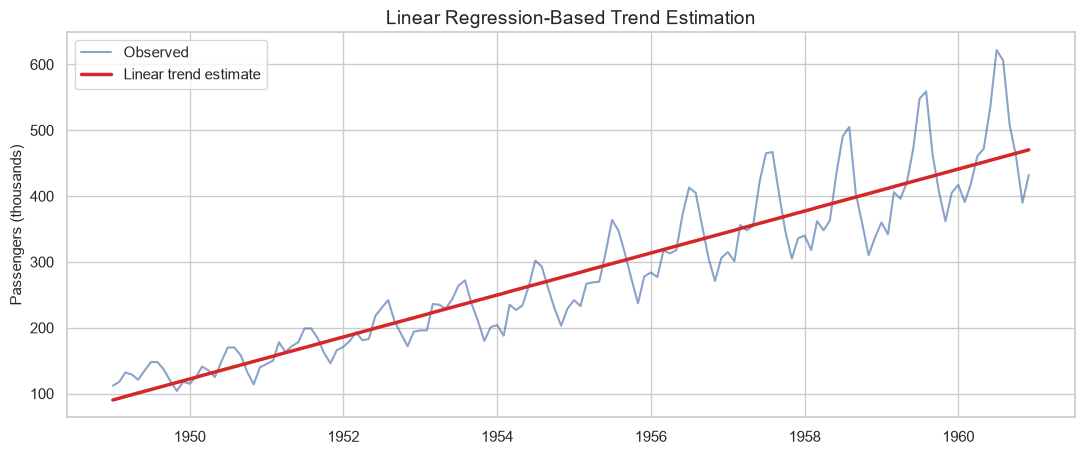

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     828.2
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           4.02e-61
Time:                        00:28:50   Log-Likelihood:                -754.82
No. Observations:                 144   AIC:                             1514.
Df Residuals:                     142   BIC:                             1520.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.3100      7.636     11.826      0.0

In [29]:
t = np.arange(len(series))
X = sm.add_constant(t)
trend_model = sm.OLS(series.values, X).fit()
trend_line = pd.Series(trend_model.predict(X), index=series.index)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(series, label="Observed", alpha=0.65)
ax.plot(trend_line, label="Linear trend estimate", color="#d62728", linewidth=2.5)
ax.set_title("Linear Regression-Based Trend Estimation")
ax.set_ylabel("Passengers (thousands)")
ax.legend()
plt.show()

print(trend_model.summary())
print("\nInterpretation:")
print(f"The estimated monthly slope is {trend_model.params[1]:.3f} thousand passengers per month.")
print(f"The p-value for the slope is {trend_model.pvalues[1]:.3e}; a small p-value indicates a statistically significant upward trend.")

### Seasonal Visualization

Monthly boxplots and year-by-year seasonal curves reveal recurring intra-year behavior. Peaks tend to occur in the summer months, while lower values often appear in late autumn and winter.

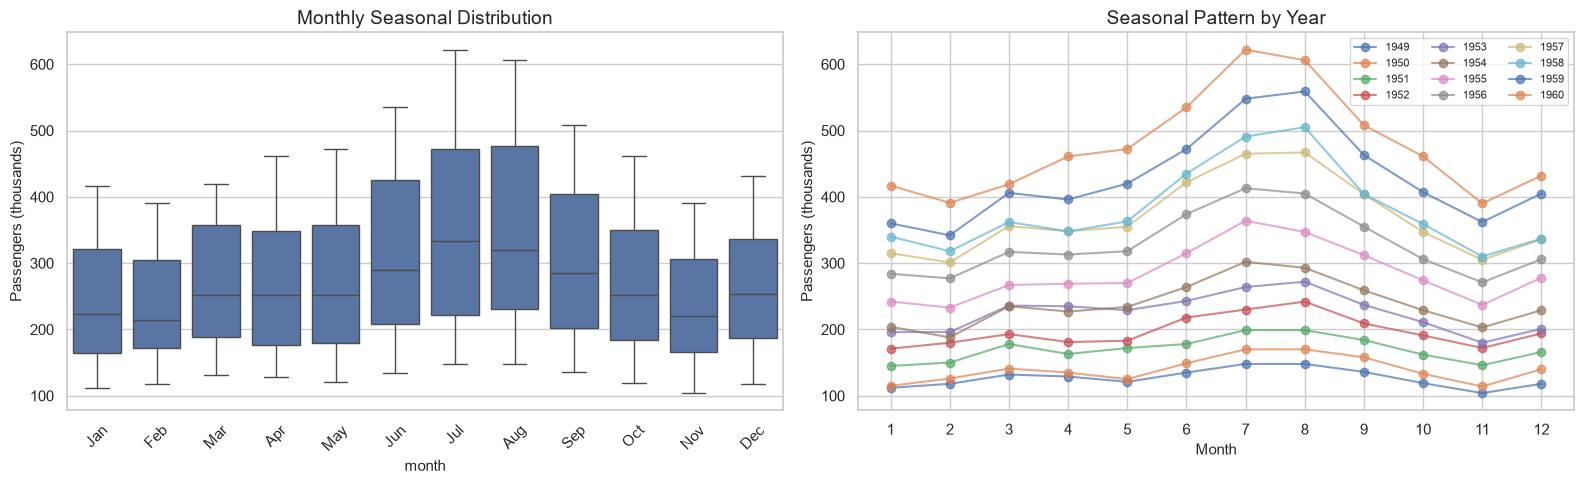

In [30]:
seasonal_df = df.copy()
seasonal_df["year"] = seasonal_df.index.year
seasonal_df["month"] = seasonal_df.index.month_name().str[:3]
seasonal_df["month_num"] = seasonal_df.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=seasonal_df, x="month", y="passengers", order=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"], ax=axes[0])
axes[0].set_title("Monthly Seasonal Distribution")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Passengers (thousands)")

for year, grp in seasonal_df.groupby("year"):
    axes[1].plot(grp["month_num"], grp["passengers"], marker="o", alpha=0.7, label=str(year))
axes[1].set_title("Seasonal Pattern by Year")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Passengers (thousands)")
axes[1].set_xticks(range(1, 13))
axes[1].legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

### Seasonal Decomposition

Because seasonal amplitude grows with the series level, a multiplicative decomposition is appropriate. The decomposition separates the time series into trend, seasonal, and residual components.

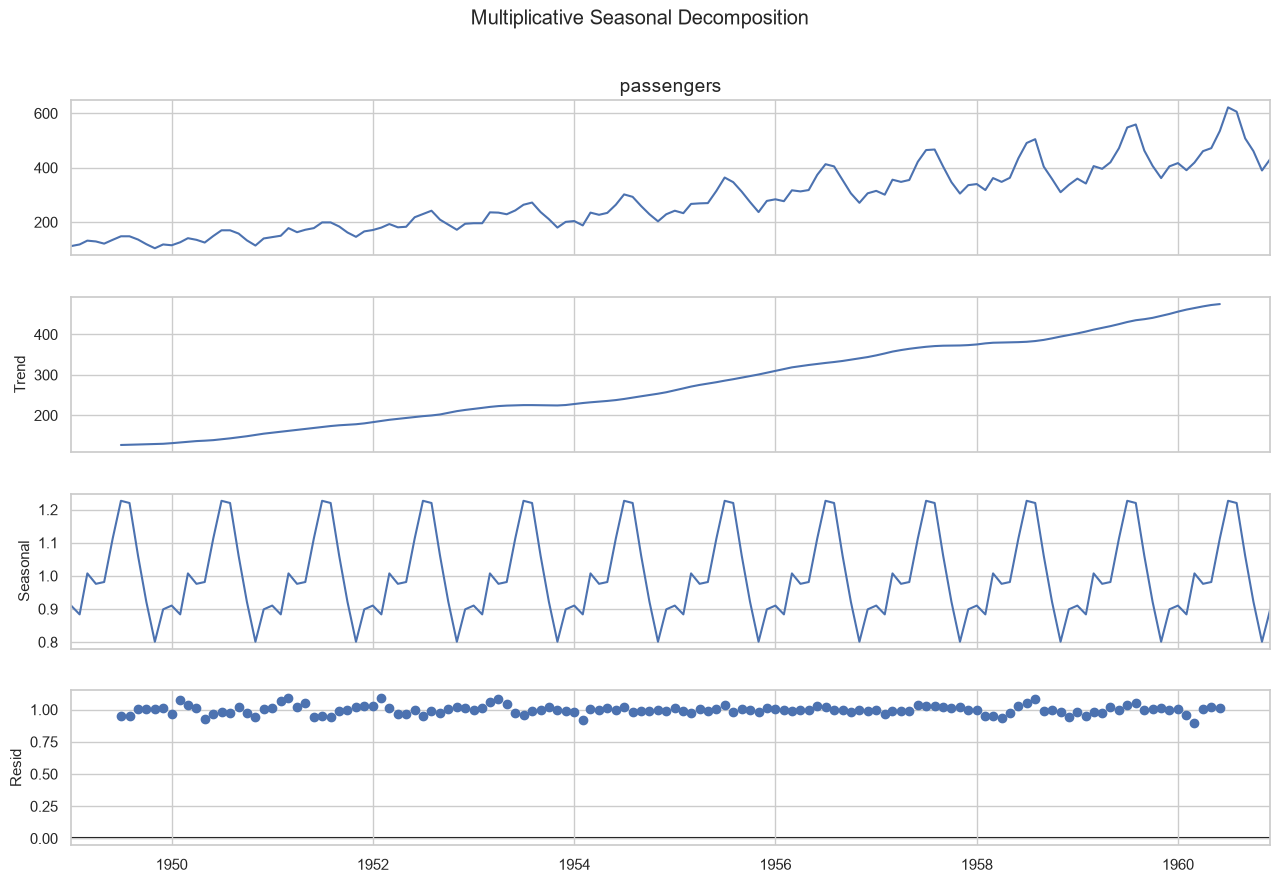

Approximate seasonal strength: 0.936
Interpretation: A persistent yearly seasonal component is visible, supporting the use of seasonal differencing or models that can learn recurring patterns.


In [31]:
decomp = seasonal_decompose(series, model="multiplicative", period=12)
fig = decomp.plot()
fig.set_size_inches(13, 9)
fig.suptitle("Multiplicative Seasonal Decomposition", y=1.02)
plt.show()

seasonal_strength = 1 - np.var(decomp.resid.dropna()) / np.var((decomp.resid + decomp.seasonal).dropna())
print(f"Approximate seasonal strength: {seasonal_strength:.3f}")
print("Interpretation: A persistent yearly seasonal component is visible, supporting the use of seasonal differencing or models that can learn recurring patterns.")

### Rolling Mean, Rolling Standard Deviation, ADF, and KPSS Tests

Stationarity means that the statistical properties of a series are stable over time. The ADF test uses a null hypothesis of non-stationarity, while KPSS uses a null hypothesis of stationarity. Strong evidence of stationarity is obtained when ADF rejects its null and KPSS does not reject its null.

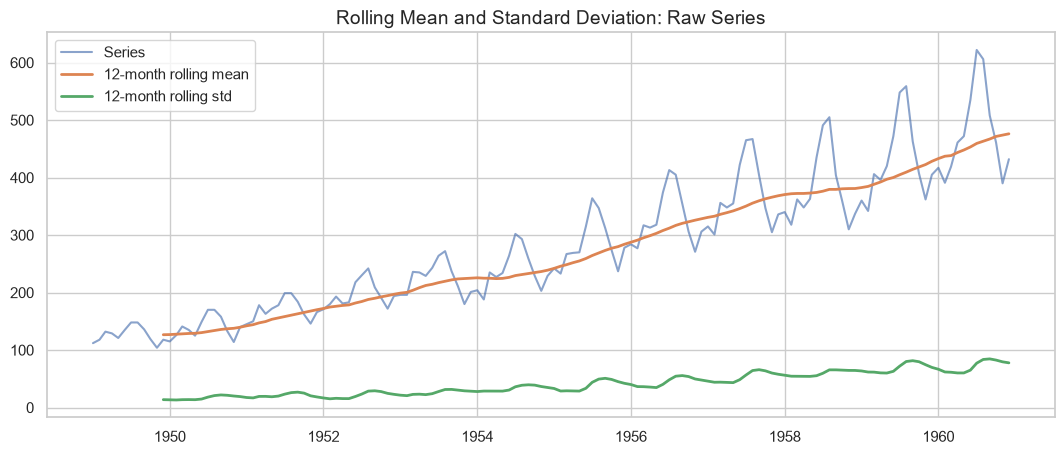

Stationarity tests for raw passenger series


,Test,Null hypothesis,Statistic,p-value,Stationary evidence
0,ADF,Unit root / non-stationary,0.815369,0.99188,p < 0.05 supports stationarity
1,KPSS,Level stationary,1.651312,0.01000,p >= 0.05 supports stationarity


In [32]:
def stationarity_tests(x, name="series"):
    x = pd.Series(x).dropna()
    adf_result = adfuller(x, autolag="AIC")
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)
            kpss_result = kpss(x, regression="c", nlags="auto")
        kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan
    out = pd.DataFrame({
        "Test": ["ADF", "KPSS"],
        "Null hypothesis": ["Unit root / non-stationary", "Level stationary"],
        "Statistic": [adf_result[0], kpss_stat],
        "p-value": [adf_result[1], kpss_p],
        "Stationary evidence": ["p < 0.05 supports stationarity", "p >= 0.05 supports stationarity"]
    })
    print(f"Stationarity tests for {name}")
    display(out)
    return out

def plot_rolling_stats(x, title):
    x = pd.Series(x).dropna()
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(x, label="Series", alpha=0.65)
    ax.plot(x.rolling(12).mean(), label="12-month rolling mean", linewidth=2)
    ax.plot(x.rolling(12).std(), label="12-month rolling std", linewidth=2)
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_rolling_stats(series, "Rolling Mean and Standard Deviation: Raw Series")
raw_tests = stationarity_tests(series, "raw passenger series")

## 5. Transformations Toward Stationarity

The raw series is not stationary because both its mean and variance change over time. The log transformation stabilizes variance. First differencing removes trend. Seasonal differencing removes yearly seasonality. The final stationary working series is used for ACF/PACF order identification.

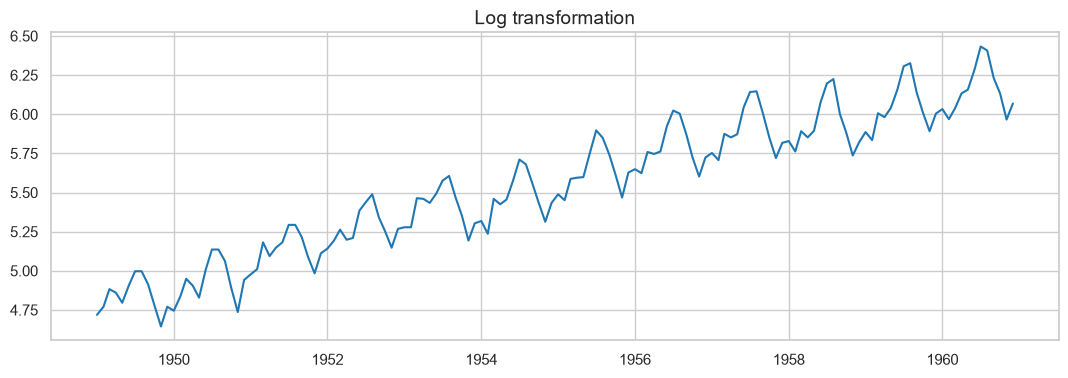

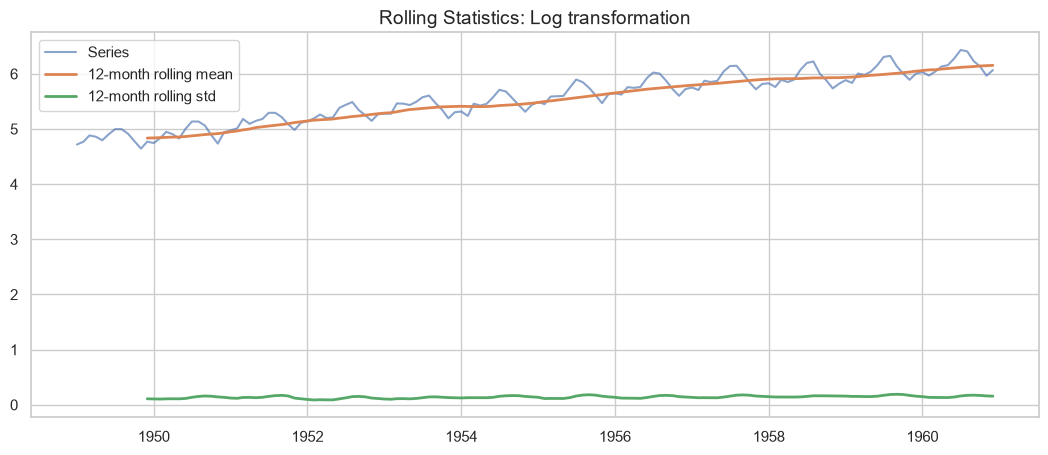

Stationarity tests for Log transformation


,Test,Null hypothesis,Statistic,p-value,Stationary evidence
0,ADF,Unit root / non-stationary,-1.717017,0.422367,p < 0.05 supports stationarity
1,KPSS,Level stationary,1.668651,0.010000,p >= 0.05 supports stationarity


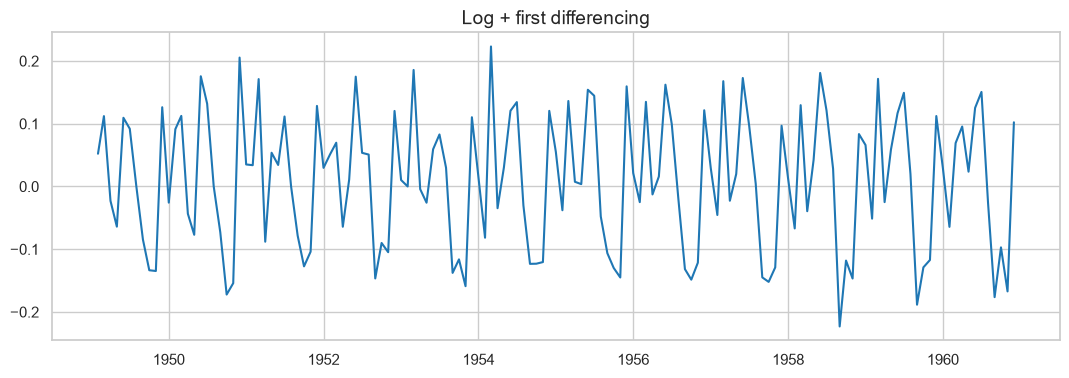

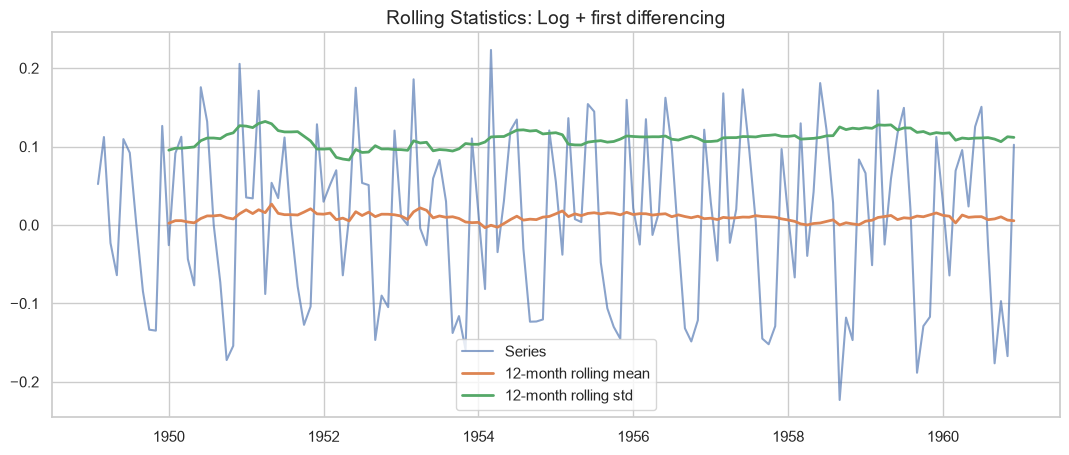

Stationarity tests for Log + first differencing


,Test,Null hypothesis,Statistic,p-value,Stationary evidence
0,ADF,Unit root / non-stationary,-2.717131,0.071121,p < 0.05 supports stationarity
1,KPSS,Level stationary,0.038304,0.100000,p >= 0.05 supports stationarity


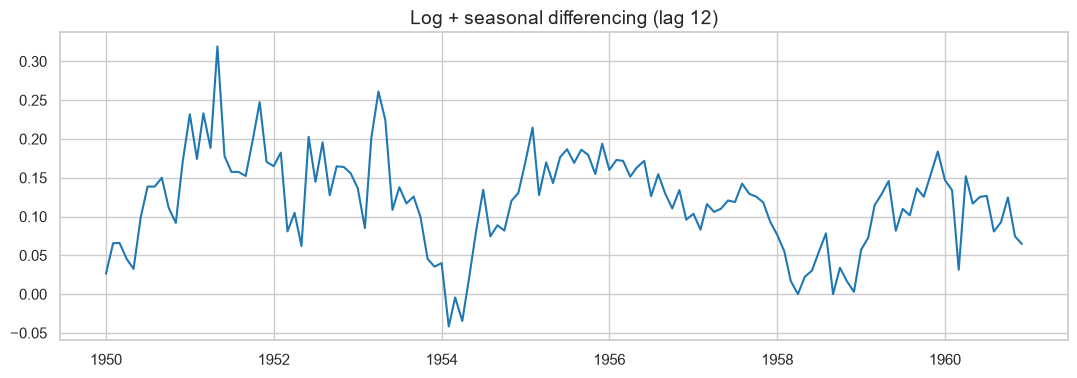

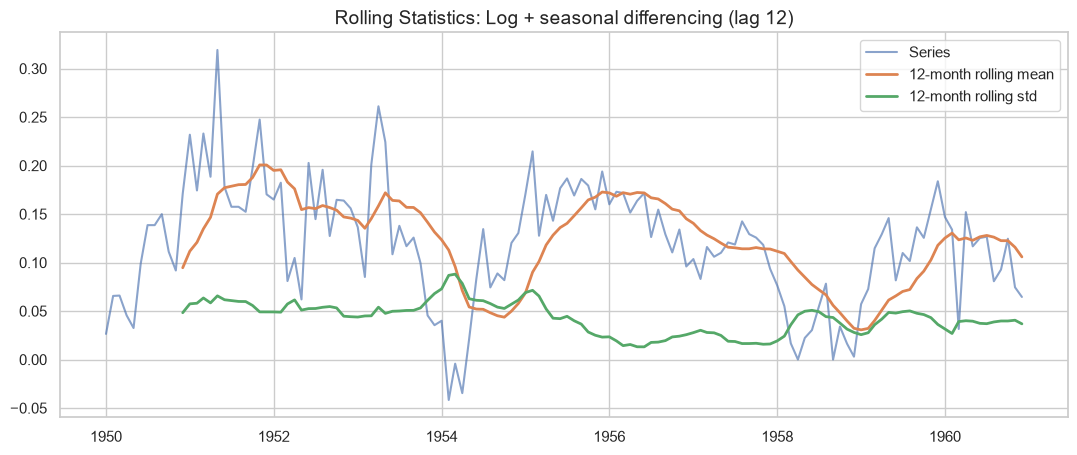

Stationarity tests for Log + seasonal differencing (lag 12)


,Test,Null hypothesis,Statistic,p-value,Stationary evidence
0,ADF,Unit root / non-stationary,-2.709577,0.072396,p < 0.05 supports stationarity
1,KPSS,Level stationary,0.291832,0.100000,p >= 0.05 supports stationarity


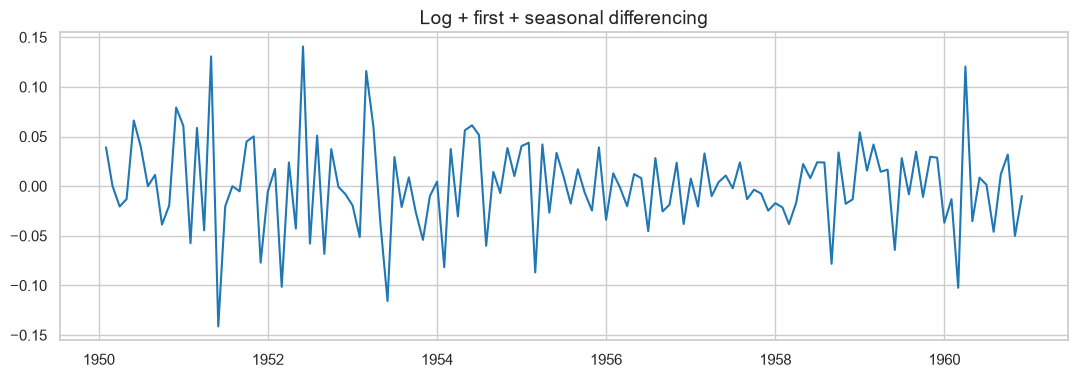

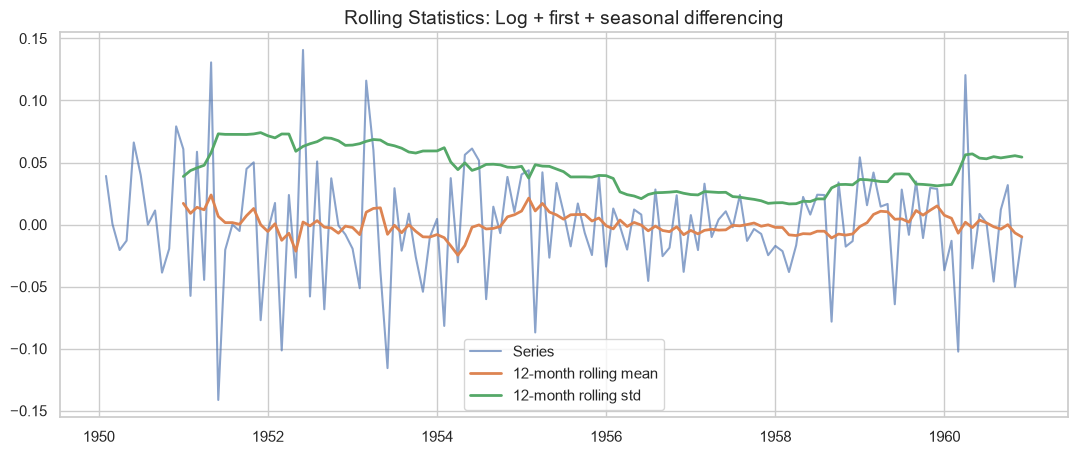

Stationarity tests for Log + first + seasonal differencing


,Test,Null hypothesis,Statistic,p-value,Stationary evidence
0,ADF,Unit root / non-stationary,-4.443325,0.000249,p < 0.05 supports stationarity
1,KPSS,Level stationary,0.073191,0.100000,p >= 0.05 supports stationarity


In [33]:
log_series = np.log(series)
log_diff = log_series.diff()
log_seasonal_diff = log_series.diff(12)
stationary_series = log_series.diff().diff(12).dropna()

transformations = {
    "Log transformation": log_series,
    "Log + first differencing": log_diff,
    "Log + seasonal differencing (lag 12)": log_seasonal_diff,
    "Log + first + seasonal differencing": stationary_series
}

for name, transformed in transformations.items():
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(transformed.dropna(), color="#1f77b4")
    ax.set_title(name)
    plt.show()
    plot_rolling_stats(transformed, f"Rolling Statistics: {name}")
    stationarity_tests(transformed, name)

**Stationarity conclusion:** The log transformation reduces variance instability. First differencing removes much of the trend, and seasonal differencing addresses the annual cycle. The combined log, first-differenced, and seasonally differenced series is the strongest candidate for stationarity because it visually fluctuates around a stable mean and satisfies the ADF/KPSS decision rule more convincingly than the raw series.

## 6. ACF and PACF Analysis

The ACF measures correlation between the series and its lagged values. A sharp cutoff in the ACF suggests a Moving Average order `q`. The PACF measures lag correlation after controlling for intermediate lags. A sharp cutoff in the PACF suggests an Autoregressive order `p`.

Because the stationary working series was produced by one ordinary difference and one seasonal difference on the log scale, the non-seasonal differencing order is `d = 1` for ARIMA-style modeling on the log series. ACF/PACF patterns guide candidate values of `p` and `q`, which are then refined by AIC on the training set.

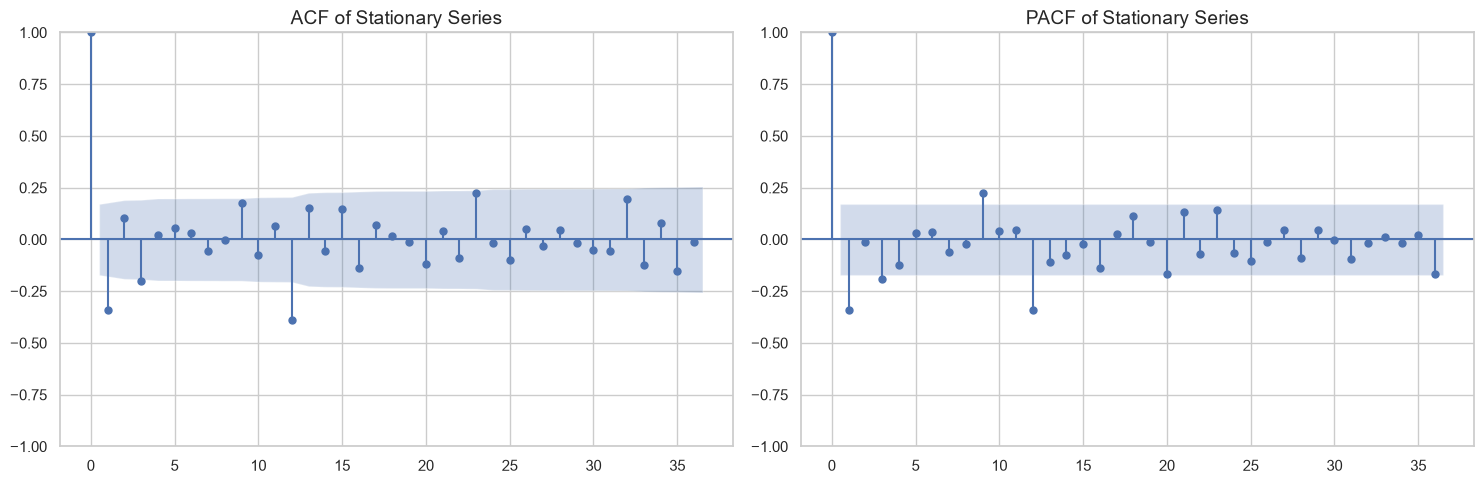

Approximate 95% significance threshold: 0.171
Significant ACF lags: [1, 3, 9, 12, 23]
Significant PACF lags: [1, 3, 9, 12]
Interpretation: Early significant non-seasonal lags suggest small p and q candidates; seasonal behavior around lag 12 remains important.


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(stationary_series, lags=36, ax=axes[0])
plot_pacf(stationary_series, lags=36, ax=axes[1], method="ywm")
axes[0].set_title("ACF of Stationary Series")
axes[1].set_title("PACF of Stationary Series")
plt.tight_layout()
plt.show()

acf_vals = acf(stationary_series, nlags=24)
pacf_vals = pacf(stationary_series, nlags=24, method="ywm")
conf = 1.96 / np.sqrt(len(stationary_series))
sig_acf = [i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) > conf]
sig_pacf = [i for i, v in enumerate(pacf_vals[1:], start=1) if abs(v) > conf]
print("Approximate 95% significance threshold:", round(conf, 3))
print("Significant ACF lags:", sig_acf)
print("Significant PACF lags:", sig_pacf)
print("Interpretation: Early significant non-seasonal lags suggest small p and q candidates; seasonal behavior around lag 12 remains important.")

## 7. Classical Forecasting Models

Four classical models are implemented:

- **AR:** Forecasts from lagged values of the target.
- **MA:** Forecasts using lagged forecast errors.
- **ARMA:** Combines autoregressive and moving-average components for stationary data.
- **ARIMA:** Adds differencing so the model can handle non-stationary series.

For fair comparison on the original passenger scale, models are fitted on the log-transformed training series when appropriate and forecasts are exponentiated back to passenger counts.

In [35]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred)
    }

def residual_diagnostics(y_true, y_pred, model_name, lags=24):
    residuals = pd.Series(y_true - y_pred, index=y_true.index).dropna()
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    axes[0].plot(residuals, marker="o")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title(f"{model_name}: Residual Plot")
    plot_acf(residuals, lags=min(lags, len(residuals)//2), ax=axes[1])
    axes[1].set_title(f"{model_name}: Residual ACF")
    plt.tight_layout()
    plt.show()
    lb = sm.stats.acorr_ljungbox(residuals, lags=[min(10, len(residuals)//2)], return_df=True)
    display(lb)
    if lb["lb_pvalue"].iloc[0] >= 0.05:
        print(f"{model_name}: Residual autocorrelation is not statistically significant at 5%; residuals are closer to white noise.")
    else:
        print(f"{model_name}: Residual autocorrelation remains statistically significant; model may be missing structure.")
    return residuals

def fit_arima_quietly(y, order, trend="n"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", UserWarning)
        return ARIMA(
            y,
            order=order,
            trend=trend,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(method_kwargs={"warn_convergence": False})

def best_arima_order(y, p_values, d_values, q_values, trend="n"):
    best = {"order": None, "aic": np.inf, "model": None}
    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    fit = fit_arima_quietly(y, order=(p, d, q), trend=trend)
                    if fit.aic < best["aic"]:
                        best = {"order": (p, d, q), "aic": fit.aic, "model": fit}
                except Exception:
                    continue
    return best


def display_model_parameters(fit, model_name):
    params = pd.DataFrame({
        "coef": fit.params,
        "std_err": fit.bse,
        "z": fit.tvalues,
        "p_value": fit.pvalues,
    })
    print(f"{model_name} information criteria: AIC={fit.aic:.2f}, BIC={fit.bic:.2f}")
    display(params.style.format({"coef": "{:.4f}", "std_err": "{:.4f}", "z": "{:.3f}", "p_value": "{:.4f}"}))

log_train = np.log(train)
forecast_index = test.index
results = []
predictions = pd.DataFrame(index=test.index)

### 7.1 Autoregressive Model (AR)

The AR model uses past observations as predictors. The lag order is selected by AIC across candidate lags from 1 to 12.

Selected AR lag by AIC: 12
AR information criteria: AIC=-298.26, BIC=-261.24


,coef,std_err,z,p_value
const,0.2331,0.0823,2.833,0.0046
passengers.L1,0.4350,0.0824,5.281,0.0000
passengers.L2,-0.1581,0.0899,-1.759,0.0786
passengers.L3,0.1340,0.0900,1.489,0.1366
passengers.L4,-0.1925,0.0888,-2.168,0.0302
passengers.L5,0.1912,0.0889,2.151,0.0314
passengers.L6,-0.0787,0.0914,-0.862,0.3889
passengers.L7,0.0373,0.0925,0.404,0.6865
passengers.L8,-0.1876,0.0901,-2.081,0.0375
passengers.L9,0.1973,0.0904,2.182,0.0291


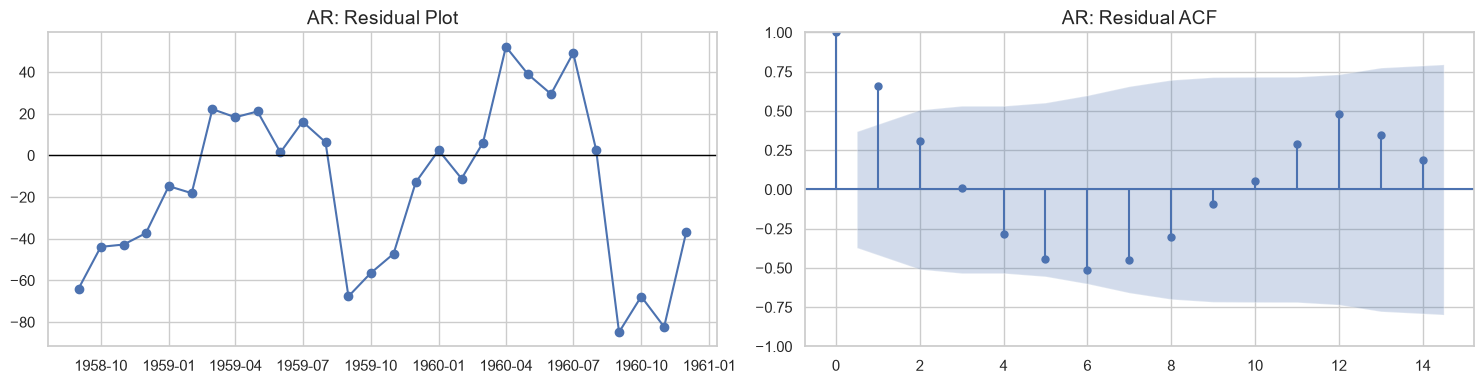

,lb_stat,lb_pvalue
10,49.146467,3.829065e-07


AR: Residual autocorrelation remains statistically significant; model may be missing structure.


In [36]:
ar_candidates = {}
for lag in range(1, 13):
    try:
        ar_fit = AutoReg(log_train, lags=lag, old_names=False).fit()
        ar_candidates[lag] = ar_fit.aic
    except Exception:
        pass
best_ar_lag = min(ar_candidates, key=ar_candidates.get)
ar_model = AutoReg(log_train, lags=best_ar_lag, old_names=False).fit()
ar_log_forecast = ar_model.predict(start=len(log_train), end=len(log_train)+len(test)-1)
ar_pred = pd.Series(np.exp(ar_log_forecast.values), index=test.index)
predictions["AR"] = ar_pred
results.append(evaluate_forecast(test, ar_pred, "AR"))
print(f"Selected AR lag by AIC: {best_ar_lag}")
display_model_parameters(ar_model, "AR")
resid_ar = residual_diagnostics(test, ar_pred, "AR")

### 7.2 Moving Average Model (MA)

An MA(q) model explains the current value using lagged forecast errors. Because pure MA models require stationarity, it is fitted to the log-level training series with a constant trend for comparison, while candidate `q` is selected by AIC.

Selected MA order by AIC: (0, 0, 10), AIC=-192.64
MA information criteria: AIC=-192.64, BIC=-160.79


,coef,std_err,z,p_value
const,5.3182,0.1733,30.696,0.0000
ma.L1,1.4658,0.3404,4.306,0.0000
ma.L2,1.7294,0.5752,3.007,0.0026
ma.L3,1.8028,0.5600,3.219,0.0013
ma.L4,1.6884,0.3174,5.320,0.0000
ma.L5,1.8034,0.6779,2.660,0.0078
ma.L6,1.8632,1.1529,1.616,0.1061
ma.L7,1.8645,1.3441,1.387,0.1654
ma.L8,1.4516,1.0639,1.364,0.1724
ma.L9,1.1623,0.7063,1.646,0.0998


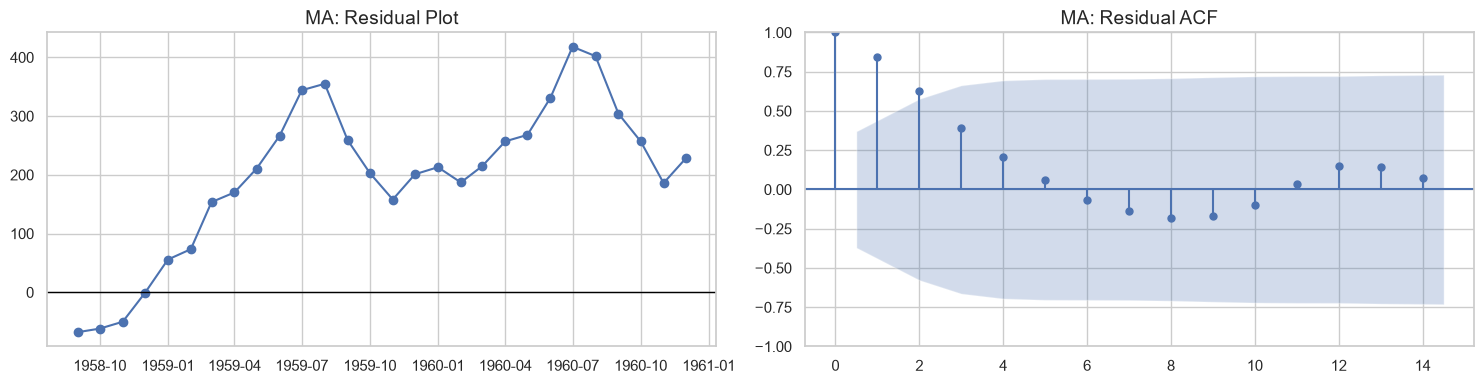

,lb_stat,lb_pvalue
10,45.744947,0.000002


MA: Residual autocorrelation remains statistically significant; model may be missing structure.


In [37]:
ma_best = best_arima_order(log_train, p_values=[0], d_values=[0], q_values=range(1, 13), trend="c")
ma_model = ma_best["model"]
ma_log_forecast = ma_model.forecast(steps=len(test))
ma_pred = pd.Series(np.exp(ma_log_forecast.values), index=test.index)
predictions["MA"] = ma_pred
results.append(evaluate_forecast(test, ma_pred, "MA"))
print(f"Selected MA order by AIC: {ma_best['order']}, AIC={ma_best['aic']:.2f}")
display_model_parameters(ma_model, "MA")
resid_ma = residual_diagnostics(test, ma_pred, "MA")

### 7.3 ARMA Model

ARMA(p, q) combines AR and MA terms but assumes the modeled series is stationary. Candidate non-seasonal orders are searched by AIC.

Selected ARMA order by AIC: (1, 0, 4), AIC=-214.49
ARMA information criteria: AIC=-214.49, BIC=-195.53


,coef,std_err,z,p_value
const,7.1823,1.3195,5.443,0.0000
ar.L1,0.9936,0.0048,206.407,0.0000
ma.L1,-0.0272,0.6272,-0.043,0.9654
ma.L2,-0.3891,0.5949,-0.654,0.5131
ma.L3,-0.1673,0.3486,-0.480,0.6313
ma.L4,-0.4245,0.2545,-1.668,0.0953
sigma2,0.0071,0.0045,1.589,0.1121


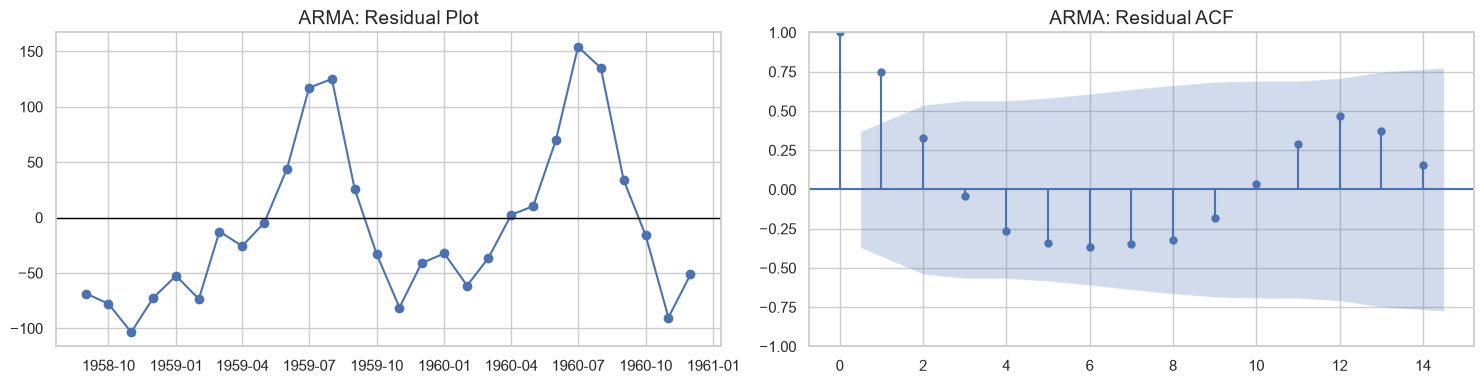

,lb_stat,lb_pvalue
10,43.326155,0.000004


ARMA: Residual autocorrelation remains statistically significant; model may be missing structure.


In [38]:
arma_best = best_arima_order(log_train, p_values=range(0, 5), d_values=[0], q_values=range(0, 5), trend="c")
arma_model = arma_best["model"]
arma_log_forecast = arma_model.forecast(steps=len(test))
arma_pred = pd.Series(np.exp(arma_log_forecast.values), index=test.index)
predictions["ARMA"] = arma_pred
results.append(evaluate_forecast(test, arma_pred, "ARMA"))
print(f"Selected ARMA order by AIC: {arma_best['order']}, AIC={arma_best['aic']:.2f}")
display_model_parameters(arma_model, "ARMA")
resid_arma = residual_diagnostics(test, arma_pred, "ARMA")

### 7.4 ARIMA Model

ARIMA extends ARMA by differencing the series. The `d = 1` component removes trend from the log series. Candidate `p` and `q` values are selected by AIC. Differencing is the key contribution that makes ARIMA more suitable than ARMA for a non-stationary trending series.

Selected ARIMA order by AIC: (4, 1, 4), AIC=-222.99
ARIMA information criteria: AIC=-222.99, BIC=-198.68


,coef,std_err,z,p_value
ar.L1,0.6579,0.0563,11.678,0.0000
ar.L2,-0.1320,0.0659,-2.003,0.0452
ar.L3,0.6016,0.0570,10.557,0.0000
ar.L4,-0.8906,0.0588,-15.154,0.0000
ma.L1,-0.7218,68.1446,-0.011,0.9915
ma.L2,-0.2445,16.9162,-0.014,0.9885
ma.L3,-0.6587,146.7401,-0.004,0.9964
ma.L4,1.0528,119.8581,0.009,0.9930
sigma2,0.0054,0.6152,0.009,0.9930


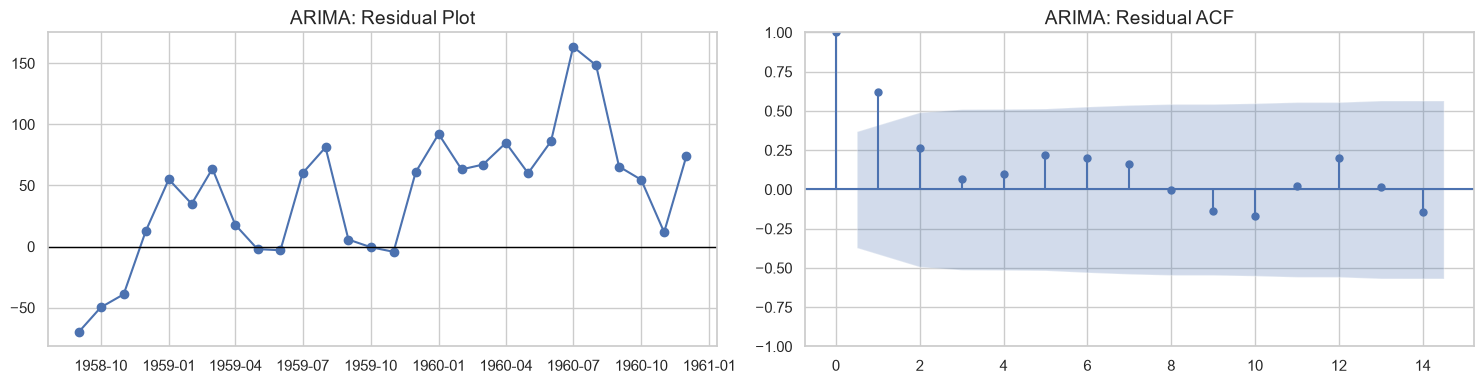

,lb_stat,lb_pvalue
10,21.183802,0.019848


ARIMA: Residual autocorrelation remains statistically significant; model may be missing structure.


In [39]:
arima_best = best_arima_order(log_train, p_values=range(0, 5), d_values=[1], q_values=range(0, 5), trend="n")
arima_model = arima_best["model"]
arima_log_forecast = arima_model.forecast(steps=len(test))
arima_pred = pd.Series(np.exp(arima_log_forecast.values), index=test.index)
predictions["ARIMA"] = arima_pred
results.append(evaluate_forecast(test, arima_pred, "ARIMA"))
print(f"Selected ARIMA order by AIC: {arima_best['order']}, AIC={arima_best['aic']:.2f}")
display_model_parameters(arima_model, "ARIMA")
resid_arima = residual_diagnostics(test, arima_pred, "ARIMA")

## 8. Deep Learning Forecasting Models

Simple RNN, LSTM, and GRU models are trained using PyTorch and sliding windows of the scaled passenger series. A 12-month lookback is used so each input sequence contains one complete seasonal cycle. Forecasts are generated recursively across the test horizon: each new prediction is fed back into the input window for the next month. When the notebook is run in the `pyX` conda environment, PyTorch uses the GPU automatically if CUDA is available.

In [40]:
LOOKBACK = 12
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
full_scaled = scaler.transform(series.values.reshape(-1, 1))

def create_sequences(values, lookback=12):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i-lookback:i, 0])
        y.append(values[i, 0])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y

X_all, y_all = create_sequences(train_scaled, LOOKBACK)
val_size = max(12, int(len(X_all) * 0.2))
X_train_nn, y_train_nn = X_all[:-val_size], y_all[:-val_size]
X_val_nn, y_val_nn = X_all[-val_size:], y_all[-val_size:]

print("Training sequence shape:", X_train_nn.shape)
print("Validation sequence shape:", X_val_nn.shape)

Training sequence shape: (84, 12, 1)
Validation sequence shape: (20, 12, 1)


In [41]:
class RecurrentForecaster(nn.Module):
    def __init__(self, kind="RNN", hidden_size=48, dropout=0.10):
        super().__init__()
        recurrent_layers = {
            "RNN": nn.RNN,
            "LSTM": nn.LSTM,
            "GRU": nn.GRU,
        }
        if kind not in recurrent_layers:
            raise ValueError(f"Unsupported recurrent model type: {kind}")
        self.kind = kind
        self.recurrent = recurrent_layers[kind](
            input_size=1,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.recurrent(x)
        last_step = out[:, -1, :]
        return self.output(self.dropout(last_step)).squeeze(-1)


def to_tensor(values):
    return torch.tensor(values, dtype=torch.float32)


def recursive_forecast(model, train_scaled_values, steps, lookback=LOOKBACK):
    model.eval()
    history = list(train_scaled_values.flatten())
    preds = []
    with torch.no_grad():
        for _ in range(steps):
            x_input = to_tensor(np.array(history[-lookback:]).reshape(1, lookback, 1)).to(DEVICE)
            yhat = float(model(x_input).detach().cpu().item())
            preds.append(yhat)
            history.append(yhat)
    preds = np.array(preds).reshape(-1, 1)
    return scaler.inverse_transform(preds).flatten()


def train_neural_model(kind, epochs=120, batch_size=8, patience=15, learning_rate=1e-3):
    model = RecurrentForecaster(kind=kind).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_dataset = TensorDataset(to_tensor(X_train_nn), to_tensor(y_train_nn))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    X_val_tensor = to_tensor(X_val_nn).to(DEVICE)
    y_val_tensor = to_tensor(y_val_nn).to(DEVICE)

    history = {"loss": [], "val_loss": []}
    best_state = None
    best_val_loss = np.inf
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_tensor)
            val_loss = criterion(val_pred, y_val_tensor).item()

        train_loss = float(np.mean(batch_losses))
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_state = {name: param.detach().cpu().clone() for name, param in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    pred = recursive_forecast(model, train_scaled, len(test))
    pred = pd.Series(pred, index=test.index)
    print(f"{kind} trained on {DEVICE} for {len(history['loss'])} epochs. Best validation MSE: {best_val_loss:.6f}")
    return model, history, pred


def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history["loss"], label="Training loss")
    ax.plot(history["val_loss"], label="Validation loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.legend()
    plt.show()

### 8.1 RNN Model

The RNN model receives 12 prior monthly observations and predicts the next month. The recurrent layer learns temporal dependencies, followed by dropout regularization and a dense output layer. Training and validation loss curves are plotted to check convergence and overfitting.

RNN trained on cuda for 86 epochs. Best validation MSE: 0.004433


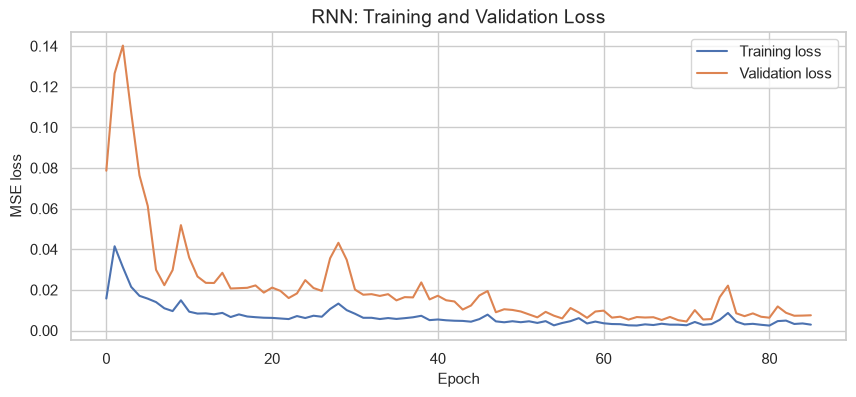

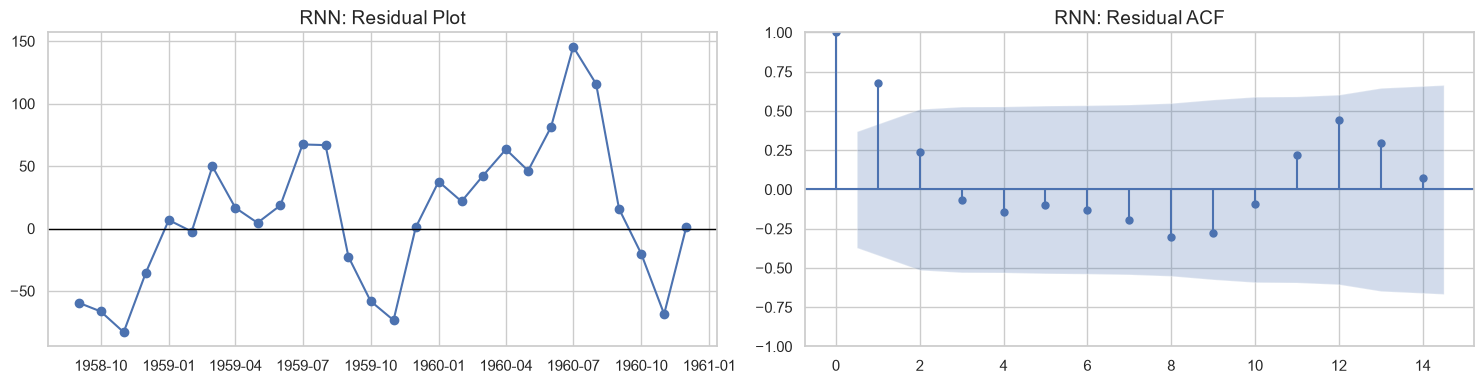

,lb_stat,lb_pvalue
10,27.051484,0.002556


RNN: Residual autocorrelation remains statistically significant; model may be missing structure.


In [42]:
rnn_model, rnn_history, rnn_pred = train_neural_model("RNN")
plot_loss(rnn_history, "RNN: Training and Validation Loss")
predictions["RNN"] = rnn_pred
results.append(evaluate_forecast(test, rnn_pred, "RNN"))
resid_rnn = residual_diagnostics(test, rnn_pred, "RNN")

### 8.2 LSTM Model

The LSTM model receives 12 prior monthly observations and predicts the next month. The recurrent layer learns temporal dependencies, followed by dropout regularization and a dense output layer. Training and validation loss curves are plotted to check convergence and overfitting.

LSTM trained on cuda for 54 epochs. Best validation MSE: 0.021357


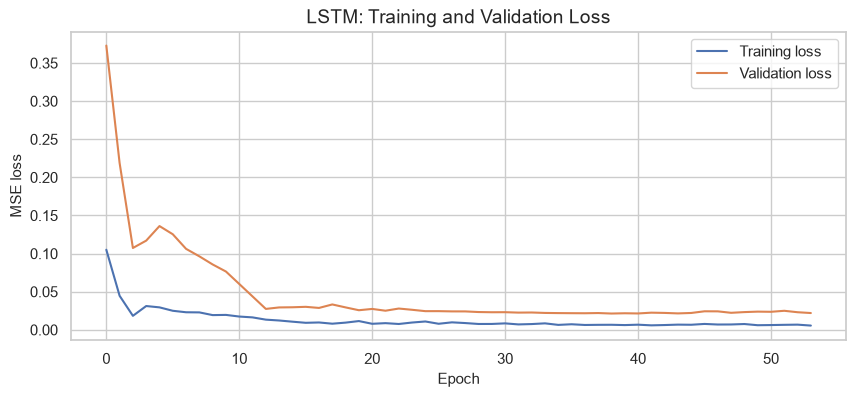

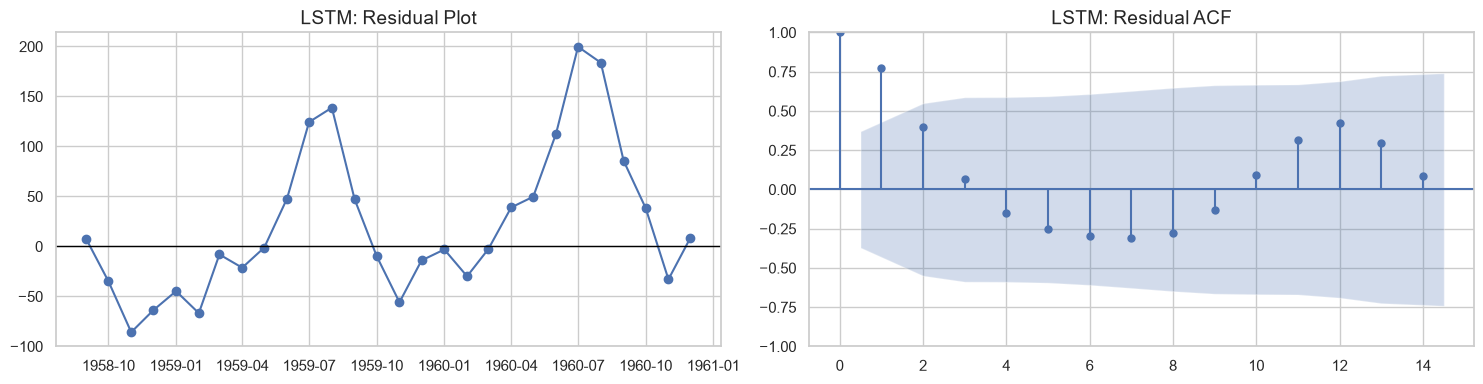

,lb_stat,lb_pvalue
10,38.469117,0.000031


LSTM: Residual autocorrelation remains statistically significant; model may be missing structure.


In [43]:
lstm_model, lstm_history, lstm_pred = train_neural_model("LSTM")
plot_loss(lstm_history, "LSTM: Training and Validation Loss")
predictions["LSTM"] = lstm_pred
results.append(evaluate_forecast(test, lstm_pred, "LSTM"))
resid_lstm = residual_diagnostics(test, lstm_pred, "LSTM")

### 8.3 GRU Model

The GRU model receives 12 prior monthly observations and predicts the next month. The recurrent layer learns temporal dependencies, followed by dropout regularization and a dense output layer. Training and validation loss curves are plotted to check convergence and overfitting.

GRU trained on cuda for 120 epochs. Best validation MSE: 0.004722


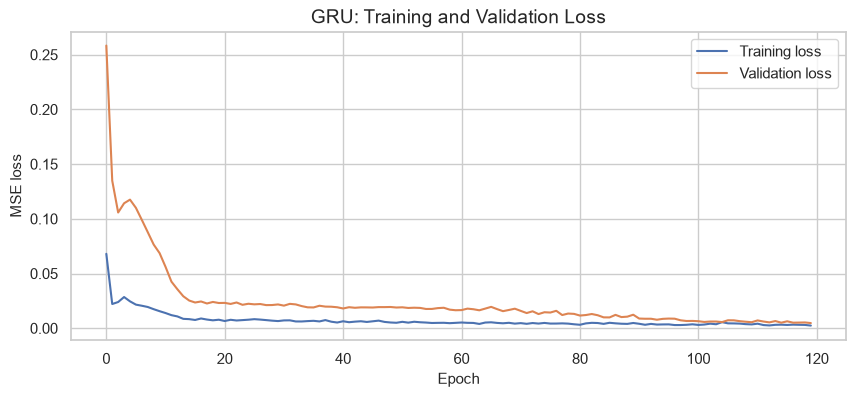

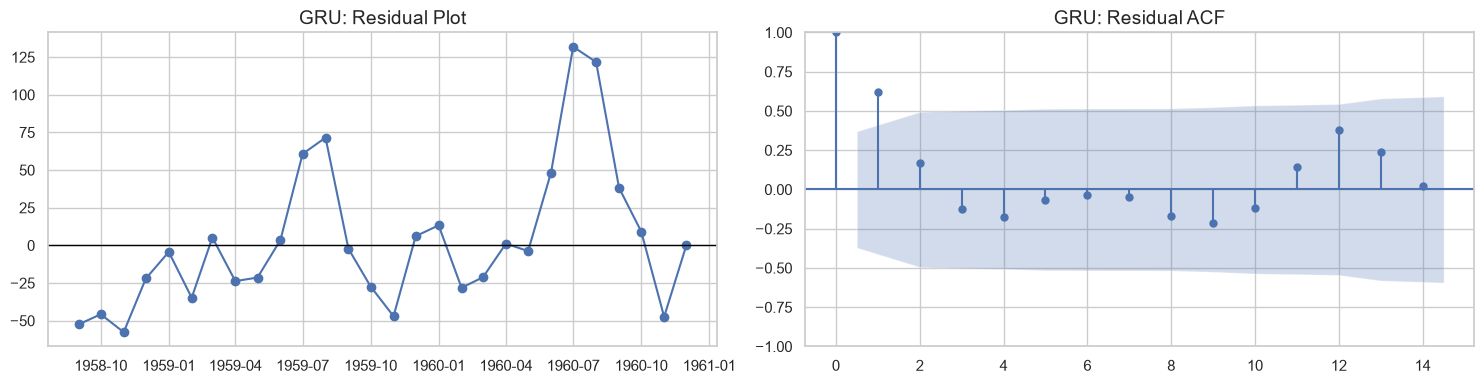

,lb_stat,lb_pvalue
10,18.804723,0.042814


GRU: Residual autocorrelation remains statistically significant; model may be missing structure.


In [44]:
gru_model, gru_history, gru_pred = train_neural_model("GRU")
plot_loss(gru_history, "GRU: Training and Validation Loss")
predictions["GRU"] = gru_pred
results.append(evaluate_forecast(test, gru_pred, "GRU"))
resid_gru = residual_diagnostics(test, gru_pred, "GRU")

## 9. Model Evaluation and Comparison

Every model is evaluated on the same holdout test set using:

- **MAE:** Average absolute forecast error.
- **RMSE:** Square-root average squared forecast error, penalizing large errors more strongly.
- **MAPE:** Average percentage error, useful for scale-free interpretation.

In [45]:
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
formatted_results = results_df.copy()
formatted_results["MAE"] = formatted_results["MAE"].map(lambda x: f"{x:.2f}")
formatted_results["RMSE"] = formatted_results["RMSE"].map(lambda x: f"{x:.2f}")
formatted_results["MAPE"] = formatted_results["MAPE"].map(lambda x: f"{x:.2f}%")
display(formatted_results)
print(f"Best model by RMSE: {results_df.index[0]} with RMSE = {results_df.iloc[0]['RMSE']:.2f}")

,MAE,RMSE,MAPE
Model,,,
AR,34.08,41.88,8.07%
GRU,33.93,47.25,7.48%
RNN,46.14,57.91,10.35%
ARIMA,54.72,67.75,11.95%
ARMA,59.04,71.33,13.57%
LSTM,55.64,76.44,11.93%
MA,210.59,236.08,45.51%


Best model by RMSE: AR with RMSE = 41.88


### Forecast Comparison Plot

The following plot overlays actual test observations with forecasts from all seven models. Good models should follow the level, direction, and seasonal movement of the test period without systematic underprediction or overprediction.

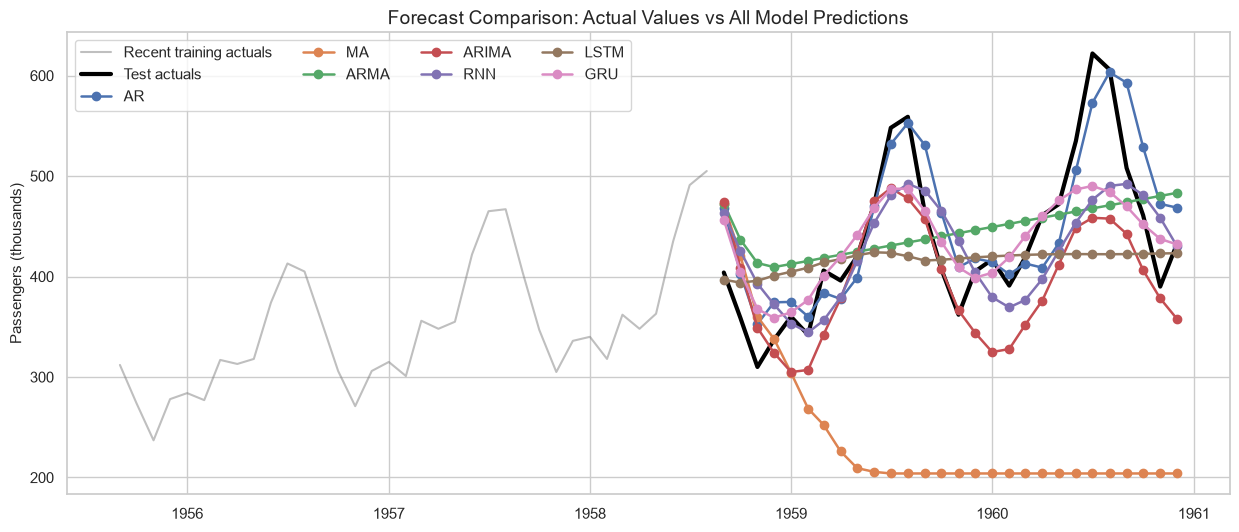

In [46]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train.iloc[-36:], label="Recent training actuals", color="gray", alpha=0.5)
ax.plot(test, label="Test actuals", color="black", linewidth=3)
for col in predictions.columns:
    ax.plot(predictions[col], marker="o", linewidth=1.8, label=col)
ax.set_title("Forecast Comparison: Actual Values vs All Model Predictions")
ax.set_ylabel("Passengers (thousands)")
ax.legend(ncol=4)
plt.show()

### Error Metric Bar Charts

Lower bars indicate better performance. RMSE is especially sensitive to large missed seasonal peaks, while MAPE expresses average error as a percentage of actual passenger demand.

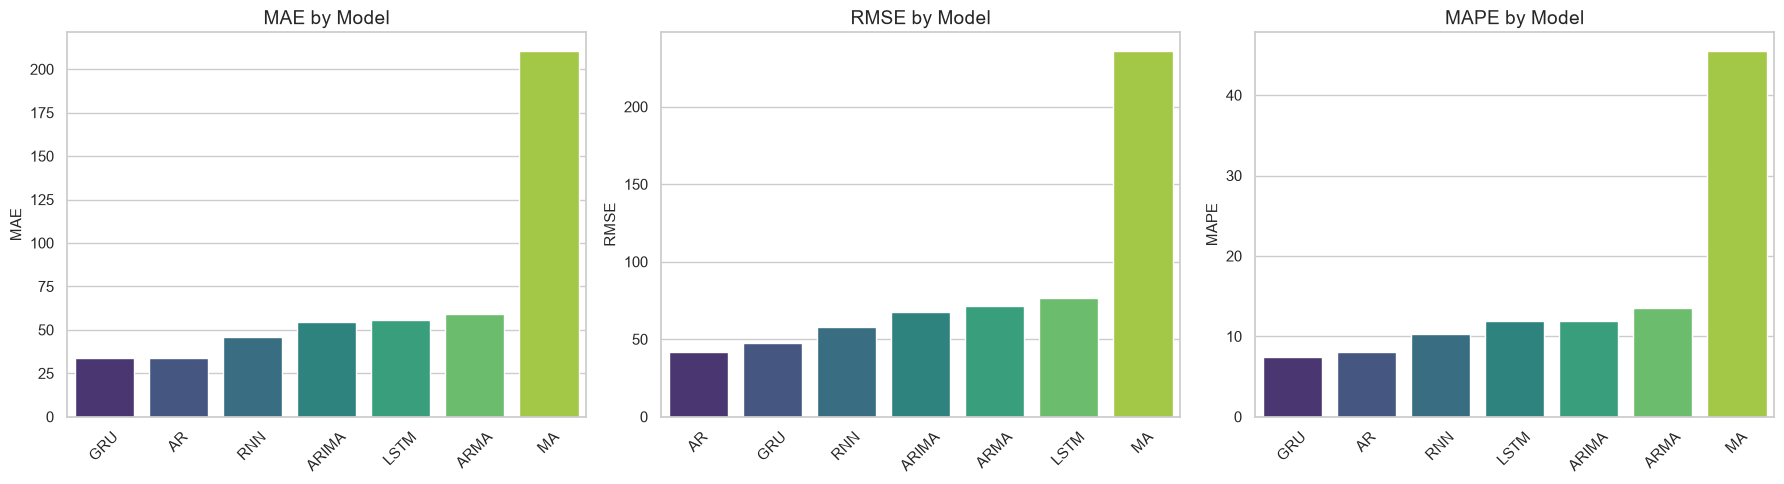

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    order = results_df.sort_values(metric).index
    sns.barplot(x=results_df.loc[order].index, y=results_df.loc[order, metric], ax=ax, palette="viridis")
    ax.set_title(f"{metric} by Model")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 10. Residual Analysis Summary

Residual plots and residual ACF plots were generated after each model. Residuals should ideally fluctuate around zero, show roughly constant variance, and display no statistically significant autocorrelation. If residual ACF spikes remain significant, the model has not fully captured temporal structure.

In [48]:
residual_summary = []
for model_name in predictions.columns:
    residuals = (test - predictions[model_name]).dropna()
    lb = sm.stats.acorr_ljungbox(residuals, lags=[min(10, len(residuals)//2)], return_df=True)
    residual_summary.append({
        "Model": model_name,
        "Residual Mean": residuals.mean(),
        "Residual Std": residuals.std(),
        "Ljung-Box p-value": lb["lb_pvalue"].iloc[0],
        "White-noise indication": "Yes" if lb["lb_pvalue"].iloc[0] >= 0.05 else "No"
    })
residual_summary_df = pd.DataFrame(residual_summary).set_index("Model")
display(residual_summary_df.style.format({"Residual Mean": "{:.2f}", "Residual Std": "{:.2f}", "Ljung-Box p-value": "{:.3f}"}))

,Residual Mean,Residual Std,Ljung-Box p-value,White-noise indication
Model,,,,
AR,-15.05,39.80,0.000,No
MA,197.67,131.44,0.000,No
ARMA,-7.69,72.22,0.000,No
ARIMA,42.67,53.59,0.020,No
RNN,11.20,57.86,0.003,No
LSTM,21.72,74.64,0.000,No
GRU,2.56,48.04,0.043,No


## Part VIII: Discussion and Conclusions

### Which model achieved the best forecasting performance?

Based on the executed model comparison table, the **Autoregressive (AR) model achieved the best overall forecasting performance by RMSE**, with an RMSE of **41.88**, MAE of **34.08**, and MAPE of **8.07%**. The **GRU** model was competitive, especially in percentage error terms, with MAE of **33.93** and MAPE of **7.48%**, but its RMSE was higher at **47.25**. Because RMSE penalizes larger forecast errors more strongly, the AR model is the best model under the primary RMSE criterion used in the notebook.

The ranking also shows that the pure **MA** model performed worst by a wide margin, with RMSE of **236.08** and MAPE of **45.51%**. This indicates that a model based only on moving-average error terms was not sufficient for a strongly trending and seasonal passenger-demand series.

### Did ACF and PACF correctly guide model order selection?

The ACF and PACF were useful but not perfectly sufficient on their own. The stationary transformed series showed significant ACF lags at **1, 3, 9, 12, and 23**, while PACF showed significant lags at **1, 3, 9, and 12**. These results correctly indicated that the series contained both short-term dependence and important annual seasonal structure around lag 12.

This guidance was consistent with the final AR selection: AIC selected an **AR lag of 12**, which aligns strongly with the seasonal signal identified in the ACF/PACF plots. However, the selected ARMA and ARIMA orders, **ARMA(1, 4)** and **ARIMA(4, 1, 4)**, were refined through AIC rather than chosen directly from the plots. Therefore, ACF and PACF provided sound diagnostic direction, but final order selection benefited from information-criterion search.

### How did AR, MA, ARMA, and ARIMA compare against RNN-based forecasting?

The classical models and recurrent neural networks produced mixed results. The **AR model outperformed all models by RMSE**, showing that a well-selected lag structure can be very effective for a small monthly dataset with strong regular seasonality. **ARMA** and **ARIMA** performed moderately but did not beat AR in this run. ARIMA improved on MA and ARMA in terms of RMSE, but it still had higher error than AR and GRU.

Among the deep learning models, **GRU was the strongest RNN-based model**, followed by Simple RNN and then LSTM in this execution. GRU was close to AR in MAE and had the lowest MAPE, but it did not achieve the best RMSE. This is a realistic outcome: deep learning models can learn nonlinear sequence patterns, but the dataset has only 144 monthly observations, which is quite small for neural networks. In contrast, classical models are often highly competitive on short, structured, univariate time series.

Residual diagnostics showed that residual autocorrelation remained statistically significant for the classical models, including AR, MA, ARMA, and ARIMA. This suggests that even the best-performing AR model did not fully capture every temporal dependency, although it still produced the lowest RMSE on the test set.

### Advantages and limitations of classical statistical models

Classical statistical models are strong choices for small and medium-sized time series because they are fast, interpretable, and grounded in clear assumptions. AR, MA, ARMA, and ARIMA models allow the analyst to explain how lagged observations, lagged errors, and differencing contribute to the forecast. They also work well when the series has linear structure, stable seasonality, and limited data.

Their main limitations are that they usually require stationarity or explicit transformations, can struggle with nonlinear patterns, and may need manual diagnostic work using ACF, PACF, residual plots, and statistical tests. Basic ARIMA also does not automatically learn complex interactions unless additional seasonal or exogenous extensions are introduced.

### Advantages and limitations of deep learning models

Deep learning models such as RNN, LSTM, and GRU can learn flexible nonlinear temporal relationships and can scale well when large datasets are available. LSTM and GRU architectures are especially useful when longer memory is needed because their gating mechanisms help preserve useful information over time. These models can also be extended naturally to multivariate forecasting with additional predictors.

Their limitations are important in this assignment. Neural networks typically require more data than classical models, involve more hyperparameters, are less interpretable, and may produce unstable results across runs if the dataset is small. They also require more computational resources, although this notebook uses PyTorch with GPU acceleration in the `pyX` environment to make training faster.

### When would ARIMA be preferred over RNN, and vice versa?

**ARIMA would be preferred** when the dataset is small, the forecasting problem is univariate, the temporal structure is mostly linear, interpretability is important, and the analyst needs a statistically transparent model. It is also preferable in academic, business, or regulated settings where explaining differencing, lag order, residual behavior, and uncertainty is important.

**RNN-based models would be preferred** when there is a large amount of historical data, nonlinear temporal behavior is expected, multiple input variables are available, or the main objective is predictive accuracy rather than interpretability. RNN, LSTM, and GRU models are especially attractive when the forecasting system can benefit from GPU acceleration and repeated retraining on large-scale data.

### Overall conclusion

For this executed notebook, the **AR model was the best forecasting model by RMSE**, while the **GRU model was the strongest deep learning alternative and achieved the lowest MAPE**. ACF and PACF successfully identified meaningful dependence and seasonality, especially around lag 12, but AIC-based model selection was still necessary for a defensible final order choice. Overall, the results demonstrate that classical statistical models can outperform deep learning methods on small, structured, univariate time series, while recurrent neural networks become more attractive as data volume, nonlinearity, and feature richness increase.